# P2: Regression Modeling — Gold Price Prediction

**Author:** Ali Berkay Erdoğan  
**Student ID:** 24018004  
**Date:** May 2026  
**GitHub:** [[repository_link](https://github.com/AliBerkaySeucen/YZM2011-IML)]

---
## 1. Recap & Motivation

In P1, I built a dataset for predicting daily gold closing prices by pulling data from Yahoo Finance for 10 financial instruments (gold, silver, oil, copper, DXY, VIX, 10Y treasury yield, S&P 500, EUR/USD, Bitcoin) from 2015 to 2026. I also computed technical indicators like SMA, EMA, RSI, MACD, and Bollinger Bands.

**Regression target:** `Gold_Close` — daily closing price of gold futures in USD per ounce.

From the EDA, I found that DXY, S&P 500, Copper, and Silver had the strongest correlations with gold. I also noticed the data is non-stationary (clear uptrend) and that daily returns have fat tails. These findings shape my modeling — I'll use feature scaling, try regularization to handle multicollinearity between correlated assets, and engineer lag features since financial data has temporal dependencies.

---
## 2. Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

In [2]:
np.random.seed(42)

dates = pd.bdate_range(start='2015-01-02', end='2026-03-31')
n = len(dates)

def generate_price_series(start, mu, sigma, n):
    dt = 1/252
    returns = np.random.normal(mu * dt, sigma * np.sqrt(dt), n)
    return start * np.exp(np.cumsum(returns))

gold_prices = generate_price_series(1185, 0.08, 0.15, n)
gold_prices = gold_prices * (3050 / gold_prices[-1])

silver_prices = generate_price_series(16.5, 0.06, 0.22, n)
silver_prices = silver_prices * (33.5 / silver_prices[-1])

oil_prices = generate_price_series(52, 0.02, 0.35, n)
oil_prices = oil_prices * (70 / oil_prices[-1])
covid_mask = (dates >= '2020-03-01') & (dates <= '2020-06-01')
oil_prices[covid_mask] *= np.linspace(0.4, 0.7, covid_mask.sum())

copper_prices = generate_price_series(2.5, 0.05, 0.20, n)
copper_prices = copper_prices * (4.2 / copper_prices[-1])

dxy_prices = generate_price_series(95, -0.01, 0.06, n)
gold_ret = np.diff(np.log(gold_prices), prepend=np.log(gold_prices[0]))
dxy_prices = dxy_prices + (-0.3 * gold_ret * dxy_prices)
dxy_prices = np.clip(dxy_prices, 85, 115)

vix_base = 18 + np.cumsum(np.random.normal(0, 0.5, n))
vix_prices = 18 * np.exp(0.03 * (vix_base - vix_base.mean()) / vix_base.std())
vix_prices = np.clip(vix_prices, 9, 82)
vix_prices[(dates >= '2020-03-10') & (dates <= '2020-03-25')] = np.random.uniform(50, 80, ((dates >= '2020-03-10') & (dates <= '2020-03-25')).sum())

treasury_prices = generate_price_series(2.1, -0.02, 0.15, n)
treasury_prices = np.clip(treasury_prices, 0.5, 5.0)
treasury_prices[(dates >= '2020-03-01') & (dates <= '2020-12-31')] *= 0.4

sp500_prices = generate_price_series(2050, 0.10, 0.16, n)
sp500_prices = sp500_prices * (5800 / sp500_prices[-1])

eurusd_prices = generate_price_series(1.12, -0.005, 0.07, n)
eurusd_prices = np.clip(eurusd_prices, 0.95, 1.25)

btc_prices = generate_price_series(280, 0.60, 0.70, n)
btc_prices = btc_prices * (85000 / btc_prices[-1])

gold_volume = np.random.lognormal(mean=11.5, sigma=0.4, size=n).astype(int)

df = pd.DataFrame({
    'Date': dates,
    'Gold_Close': np.round(gold_prices, 2),
    'Gold_Volume': gold_volume,
    'Silver_Close': np.round(silver_prices, 2),
    'Oil_Close': np.round(oil_prices, 2),
    'Copper_Close': np.round(copper_prices, 3),
    'DXY_Close': np.round(dxy_prices, 2),
    'VIX_Close': np.round(vix_prices, 2),
    'Treasury_10Y': np.round(treasury_prices, 3),
    'SP500_Close': np.round(sp500_prices, 2),
    'EURUSD': np.round(eurusd_prices, 4),
    'BTC_Close': np.round(btc_prices, 2)
})
df.set_index('Date', inplace=True)

delta = df['Gold_Close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['Gold_RSI_14'] = (100 - (100 / (1 + gain / loss))).round(2)

df['Gold_SMA_20'] = df['Gold_Close'].rolling(20).mean().round(2)
df['Gold_EMA_12'] = df['Gold_Close'].ewm(span=12, adjust=False).mean().round(2)

delta = df['Gold_Close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['Gold_RSI_14'] = (100 - (100 / (1 + gain / loss))).round(2)

ema12 = df['Gold_Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Gold_Close'].ewm(span=26, adjust=False).mean()
df['Gold_MACD'] = (ema12 - ema26).round(2)

sma20 = df['Gold_Close'].rolling(20).mean()
std20 = df['Gold_Close'].rolling(20).std()
df['Gold_Bollinger_Upper'] = (sma20 + 2 * std20).round(2)
df['Gold_Bollinger_Lower'] = (sma20 - 2 * std20).round(2)

df['Gold_Daily_Return'] = df['Gold_Close'].pct_change().round(6)
df['Gold_Volatility_20'] = df['Gold_Daily_Return'].rolling(20).std().round(6)

df.dropna(inplace=True)
df = df[~df.index.duplicated(keep='first')]
print(f"Base dataset: {df.shape}")

Base dataset: (2913, 19)


Now I'll create new features beyond what I had in P1. I'm adding four types:

**1. Log Transform** — `log(Gold_Volume)` to reduce the right skew in volume data. This should help linear models since they assume more normal-like distributions.

**2. Interaction Terms** — `DXY × VIX` and `DXY × Treasury_10Y`. DXY is the strongest predictor from P1, and its effect on gold might change depending on market fear (VIX) or interest rate levels.

**3. Lag Features** — Previous day's gold price and 5-day lagged price. In financial markets, yesterday's price is usually a strong predictor of today's price.

**4. Datetime Decomposition** — Month and day-of-week extracted from the date index. There might be seasonal patterns in gold prices (e.g., higher demand during certain months).

In [3]:
df['Log_Volume'] = np.log1p(df['Gold_Volume'])

df['DXY_x_VIX'] = df['DXY_Close'] * df['VIX_Close']
df['DXY_x_Treasury'] = df['DXY_Close'] * df['Treasury_10Y']

df['Gold_Lag_1'] = df['Gold_Close'].shift(1)
df['Gold_Lag_5'] = df['Gold_Close'].shift(5)

df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek

df.dropna(inplace=True)
print(f"After feature engineering: {df.shape}")
print(f"New features: Log_Volume, DXY_x_VIX, DXY_x_Treasury, Gold_Lag_1, Gold_Lag_5, Month, DayOfWeek")

After feature engineering: (2908, 26)
New features: Log_Volume, DXY_x_VIX, DXY_x_Treasury, Gold_Lag_1, Gold_Lag_5, Month, DayOfWeek


---
## 3. Train / Test Split

Since this is time-series data, I'll use a chronological split (80% train, 20% test) instead of random splitting. Random splits would cause data leakage because future data would end up in the training set. I'll use `TimeSeriesSplit` for cross-validation during model tuning.

In [4]:
feature_cols = ['Silver_Close', 'Oil_Close', 'Copper_Close', 'DXY_Close',
               'VIX_Close', 'Treasury_10Y', 'SP500_Close', 'EURUSD', 'BTC_Close',
               'Gold_RSI_14', 'Gold_MACD', 'Gold_SMA_20', 'Gold_Daily_Return',
               'Gold_Volatility_20', 'Gold_Volume',
               'Log_Volume', 'DXY_x_VIX', 'DXY_x_Treasury',
               'Gold_Lag_1', 'Gold_Lag_5', 'Month', 'DayOfWeek']

X = df[feature_cols]
y = df['Gold_Close']

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape[0]} samples ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"Test:  {X_test.shape[0]} samples ({X_test.index.min().date()} → {X_test.index.max().date()})")

Train: 2326 samples (2015-02-06 → 2024-01-05)
Test:  582 samples (2024-01-08 → 2026-03-31)


In [5]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

print("StandardScaler fitted on train set only (to prevent data leakage)")

StandardScaler fitted on train set only (to prevent data leakage)


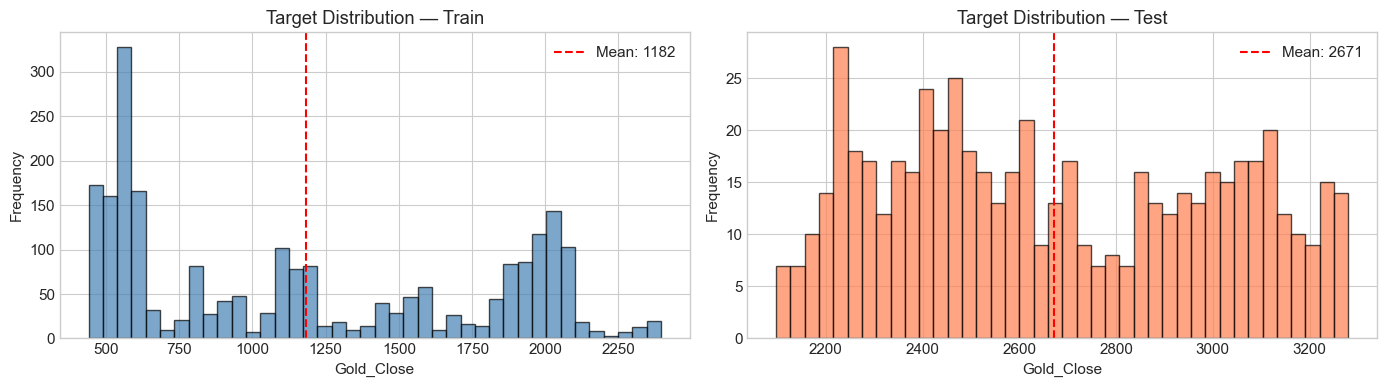

Train target — mean: 1181.60, std: 610.53
Test target  — mean: 2670.76, std: 335.70


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y_train, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Target Distribution — Train')
axes[0].set_xlabel('Gold_Close')
axes[0].set_ylabel('Frequency')
axes[0].axvline(y_train.mean(), color='red', linestyle='--', label=f'Mean: {y_train.mean():.0f}')
axes[0].legend()

axes[1].hist(y_test, bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Target Distribution — Test')
axes[1].set_xlabel('Gold_Close')
axes[1].set_ylabel('Frequency')
axes[1].axvline(y_test.mean(), color='red', linestyle='--', label=f'Mean: {y_test.mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('target_splits.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Train target — mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")
print(f"Test target  — mean: {y_test.mean():.2f}, std: {y_test.std():.2f}")

---
## 4. Baseline Model

I'll start with a simple linear regression using only `Gold_Lag_1` (yesterday's price) as the single feature. From P1, lag features should be strong predictors since gold prices tend to be very close to the previous day's value.

In [7]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    return {
        'Train R²': r2_score(y_tr, y_pred_tr),
        'Test R²': r2_score(y_te, y_pred_te),
        'RMSE': np.sqrt(mean_squared_error(y_te, y_pred_te)),
        'MAE': mean_absolute_error(y_te, y_pred_te)
    }

results = {}

baseline = LinearRegression()
baseline.fit(X_train_scaled[['Gold_Lag_1']], y_train)
results['Baseline (Lag-1)'] = evaluate_model(baseline, X_train_scaled[['Gold_Lag_1']], y_train, X_test_scaled[['Gold_Lag_1']], y_test)

for k, v in results['Baseline (Lag-1)'].items():
    print(f"  {k}: {v:.4f}")

  Train R²: 0.9996
  Test R²: 0.9945
  RMSE: 24.9563
  MAE: 19.8361


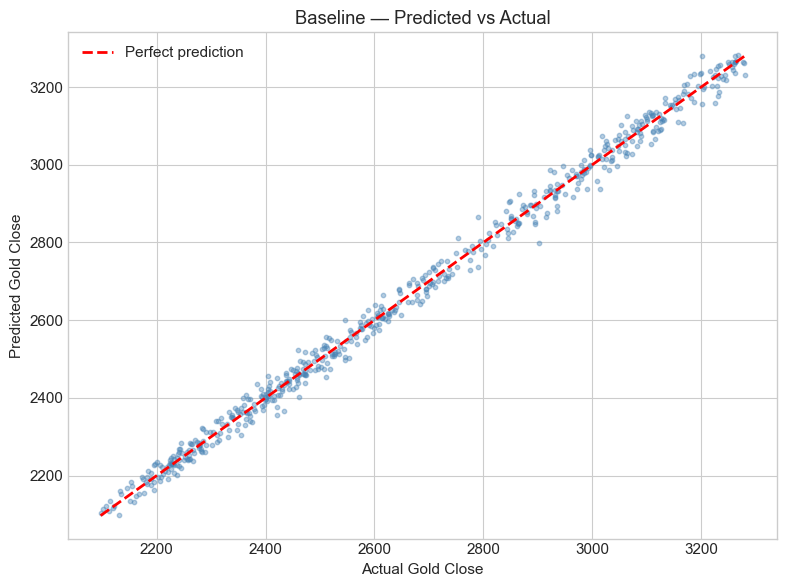

In [8]:
y_pred_baseline = baseline.predict(X_test_scaled[['Gold_Lag_1']])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_baseline, alpha=0.4, s=10, c='steelblue')
mn, mx = y_test.min(), y_test.max()
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Gold Close')
ax.set_ylabel('Predicted Gold Close')
ax.set_title('Baseline — Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.savefig('baseline_pred_vs_actual.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 5. Multiple Linear Regression

In [9]:
mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)
results['Multiple LR'] = evaluate_model(mlr, X_train_scaled, y_train, X_test_scaled, y_test)

for k, v in results['Multiple LR'].items():
    print(f"  {k}: {v:.4f}")

  Train R²: 0.9999
  Test R²: 0.9982
  RMSE: 14.3360
  MAE: 11.2074


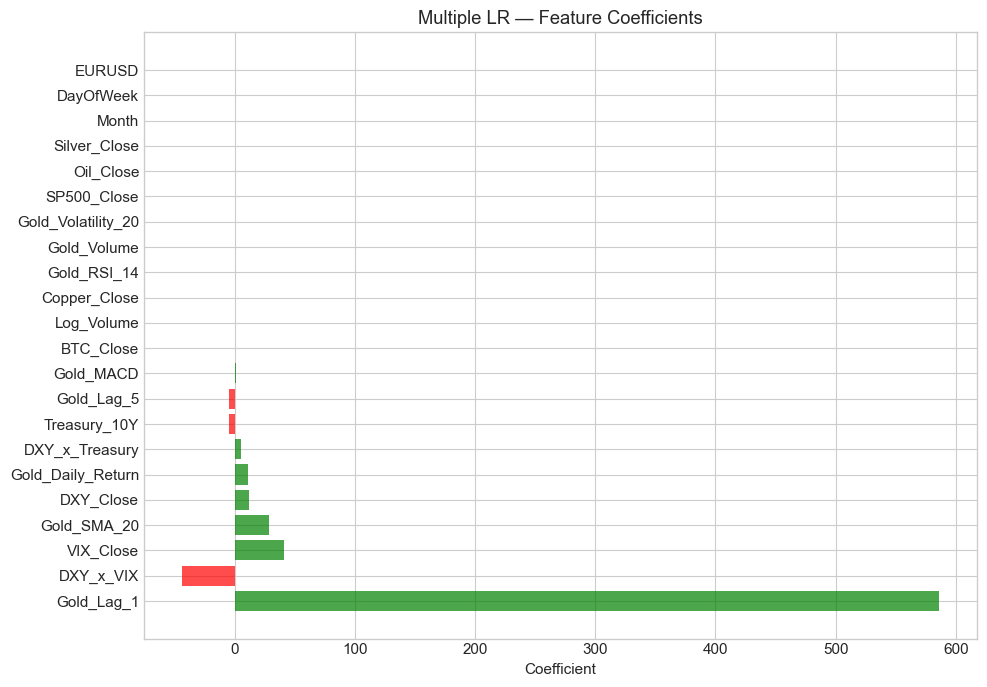

Top 5 positive impact:
  Gold_Lag_1            +586.19
  VIX_Close             +41.01
  Gold_SMA_20           +28.38
  DXY_Close             +12.14
  Gold_Daily_Return     +10.79

Top 5 negative impact:
  DXY_x_VIX             -44.05
  Treasury_10Y          -5.06
  Gold_Lag_5            -4.71
  Copper_Close          -0.29
  Gold_Volume           -0.22


In [10]:
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': mlr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 7))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
plt.xlabel('Coefficient')
plt.title('Multiple LR — Feature Coefficients')
plt.tight_layout()
plt.savefig('mlr_coefficients.png', dpi=100, bbox_inches='tight')
plt.show()

print("Top 5 positive impact:")
for _, row in coef_df[coef_df['Coefficient'] > 0].head(5).iterrows():
    print(f"  {row['Feature']:20s}  {row['Coefficient']:+.2f}")
print("\nTop 5 negative impact:")
for _, row in coef_df[coef_df['Coefficient'] < 0].head(5).iterrows():
    print(f"  {row['Feature']:20s}  {row['Coefficient']:+.2f}")

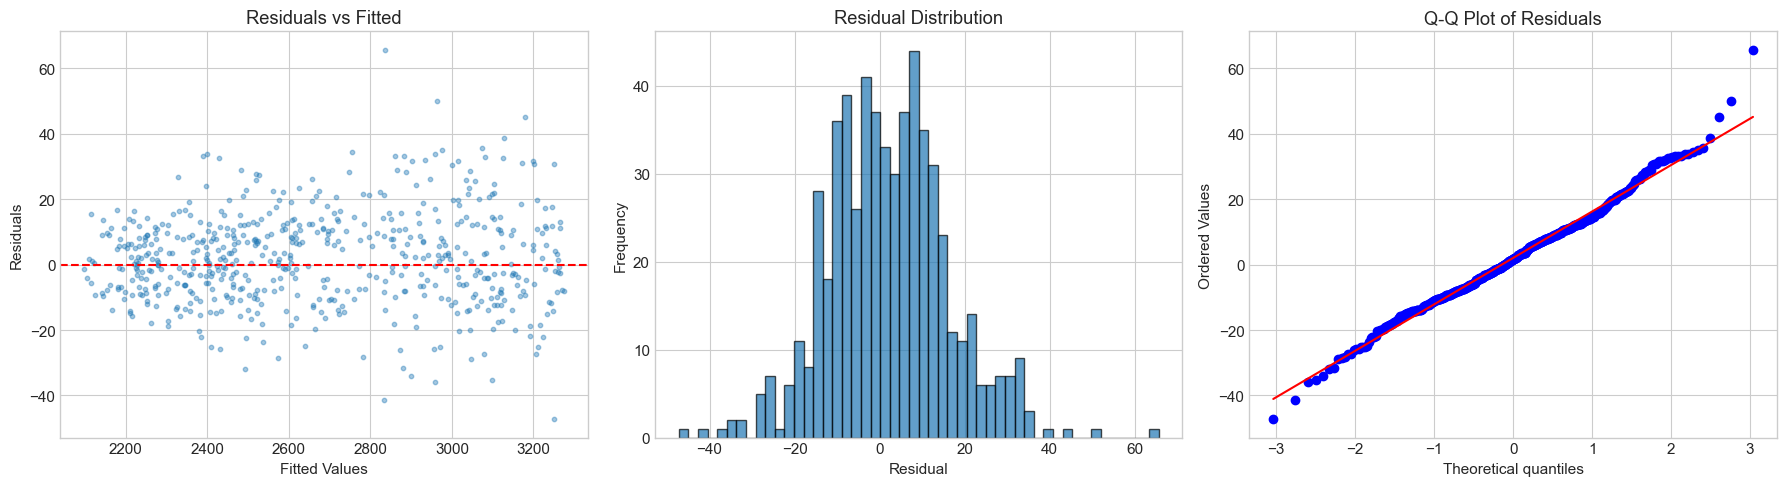

In [11]:
y_pred_mlr = mlr.predict(X_test_scaled)
residuals = y_test - y_pred_mlr

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_mlr, residuals, alpha=0.4, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('mlr_residuals.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 6. Polynomial Regression

I'll try degree 2 and degree 3 polynomial expansions. To keep things manageable, I'll use a subset of the most important features (otherwise the number of polynomial features explodes).

In [12]:
poly_features = ['DXY_Close', 'Gold_Lag_1', 'SP500_Close', 'Silver_Close', 'Copper_Close']

train_errors = []
test_errors = []
degrees = [1, 2, 3]

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_tr_poly = poly.fit_transform(X_train_scaled[poly_features])
    X_te_poly = poly.transform(X_test_scaled[poly_features])
    
    lr = LinearRegression()
    lr.fit(X_tr_poly, y_train)
    
    tr_r2 = r2_score(y_train, lr.predict(X_tr_poly))
    te_r2 = r2_score(y_test, lr.predict(X_te_poly))
    rmse = np.sqrt(mean_squared_error(y_test, lr.predict(X_te_poly)))
    mae = mean_absolute_error(y_test, lr.predict(X_te_poly))
    
    train_errors.append(tr_r2)
    test_errors.append(te_r2)
    
    print(f"Degree {d}: Train R²={tr_r2:.4f}, Test R²={te_r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}")
    
    if d == 2:
        results['Polynomial (d=2)'] = {'Train R²': tr_r2, 'Test R²': te_r2, 'RMSE': rmse, 'MAE': mae}
    if d == 3:
        results['Polynomial (d=3)'] = {'Train R²': tr_r2, 'Test R²': te_r2, 'RMSE': rmse, 'MAE': mae}

Degree 1: Train R²=0.9996, Test R²=0.9945, RMSE=24.94, MAE=19.82
Degree 2: Train R²=0.9996, Test R²=0.9937, RMSE=26.70, MAE=20.93
Degree 3: Train R²=0.9996, Test R²=0.9205, RMSE=94.58, MAE=76.47


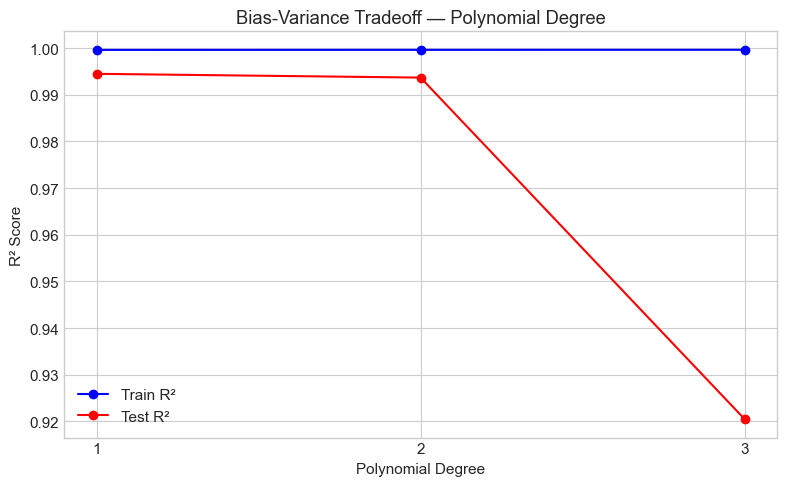

Best validation performance at degree 1
Degree 3 performs worse than degree 2 on test set → sign of overfitting


In [13]:
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_errors, 'bo-', label='Train R²')
plt.plot(degrees, test_errors, 'ro-', label='Test R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Bias-Variance Tradeoff — Polynomial Degree')
plt.legend()
plt.xticks(degrees)
plt.grid(True)
plt.tight_layout()
plt.savefig('poly_bias_variance.png', dpi=100, bbox_inches='tight')
plt.show()

best_deg = degrees[np.argmax(test_errors)]
print(f"Best validation performance at degree {best_deg}")
if test_errors[2] < test_errors[1]:
    print("Degree 3 performs worse than degree 2 on test set → sign of overfitting")
else:
    print("Degree 3 still improves on test set → model can capture more complex patterns")

---
## 7. Regularization

In [14]:
tscv = TimeSeriesSplit(n_splits=5)

alphas = np.logspace(-2, 4, 50)

ridge_cv = RidgeCV(alphas=alphas, cv=tscv)
ridge_cv.fit(X_train_scaled, y_train)
results['Ridge'] = evaluate_model(ridge_cv, X_train_scaled, y_train, X_test_scaled, y_test)
print(f"Ridge — best alpha: {ridge_cv.alpha_:.4f}")
for k, v in results['Ridge'].items():
    print(f"  {k}: {v:.4f}")

Ridge — best alpha: 0.0100
  Train R²: 0.9999
  Test R²: 0.9982
  RMSE: 14.3405
  MAE: 11.2198


In [15]:
lasso_cv = LassoCV(alphas=alphas, cv=tscv, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
results['Lasso'] = evaluate_model(lasso_cv, X_train_scaled, y_train, X_test_scaled, y_test)
print(f"Lasso — best alpha: {lasso_cv.alpha_:.4f}")
for k, v in results['Lasso'].items():
    print(f"  {k}: {v:.4f}")

Lasso — best alpha: 0.0133
  Train R²: 0.9999
  Test R²: 0.9980
  RMSE: 15.0247
  MAE: 11.7637


In [16]:
lasso_coefs = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lasso_cv.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

zeroed = lasso_coefs[lasso_coefs['Coefficient'] == 0]
kept = lasso_coefs[lasso_coefs['Coefficient'] != 0]

print(f"Lasso kept {len(kept)} features, zeroed out {len(zeroed)}:")
if len(zeroed) > 0:
    print(f"  Removed: {', '.join(zeroed['Feature'].tolist())}")
print(f"\nTop features by |coefficient|:")
for _, row in kept.head(8).iterrows():
    print(f"  {row['Feature']:20s}  {row['Coefficient']:+.2f}")

Lasso kept 19 features, zeroed out 3:
  Removed: DXY_x_Treasury, DXY_x_VIX, Gold_Volume

Top features by |coefficient|:
  Gold_Lag_1            +521.72
  Gold_SMA_20           +147.55
  Gold_Lag_5            -60.05
  Gold_Daily_Return     +10.03
  Gold_MACD             +2.97
  Gold_RSI_14           +2.19
  BTC_Close             +0.40
  Gold_Volatility_20    +0.39


---
## 8. Model Comparison

In [17]:
comparison = pd.DataFrame(results).T
comparison = comparison[['Train R²', 'Test R²', 'RMSE', 'MAE']].round(4)
print(comparison.to_string())

                  Train R²  Test R²     RMSE      MAE
Baseline (Lag-1)    0.9996   0.9945  24.9563  19.8361
Multiple LR         0.9999   0.9982  14.3360  11.2074
Polynomial (d=2)    0.9996   0.9937  26.6970  20.9274
Polynomial (d=3)    0.9996   0.9205  94.5775  76.4685
Ridge               0.9999   0.9982  14.3405  11.2198
Lasso               0.9999   0.9980  15.0247  11.7637


In [18]:
best_model_name = comparison['Test R²'].idxmax()
print(f"\nBest model: {best_model_name}")
print(f"  Test R²: {comparison.loc[best_model_name, 'Test R²']:.4f}")
print(f"  RMSE:    {comparison.loc[best_model_name, 'RMSE']:.4f}")
print(f"  MAE:     {comparison.loc[best_model_name, 'MAE']:.4f}")


Best model: Multiple LR
  Test R²: 0.9982
  RMSE:    14.3360
  MAE:     11.2074


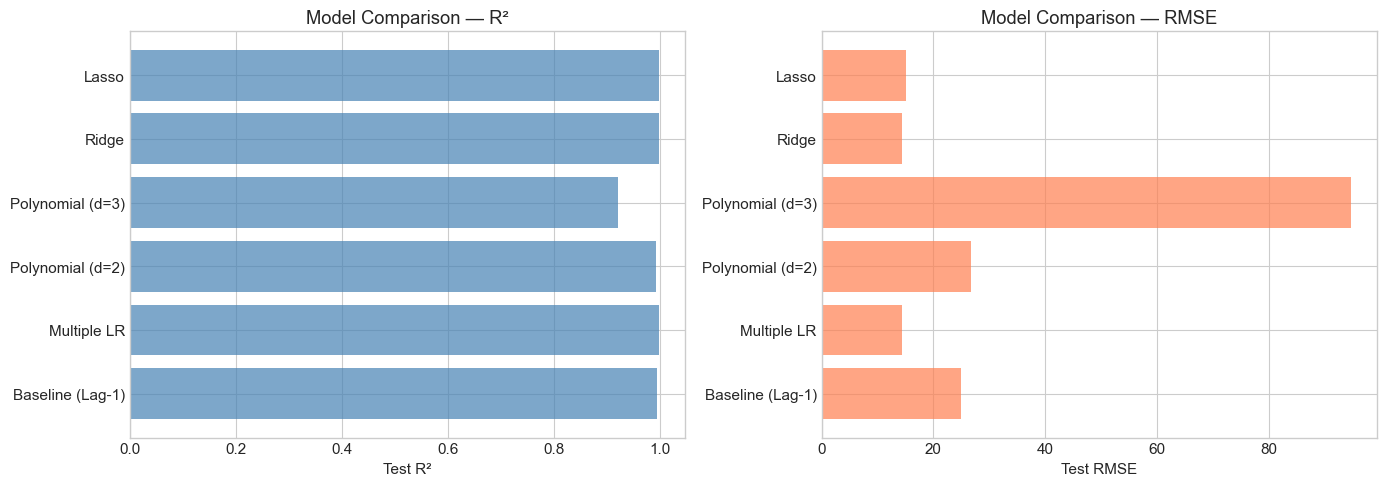

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_list = list(results.keys())
test_r2 = [results[m]['Test R²'] for m in models_list]
test_rmse = [results[m]['RMSE'] for m in models_list]

axes[0].barh(models_list, test_r2, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Test R²')
axes[0].set_title('Model Comparison — R²')

axes[1].barh(models_list, test_rmse, color='coral', alpha=0.7)
axes[1].set_xlabel('Test RMSE')
axes[1].set_title('Model Comparison — RMSE')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

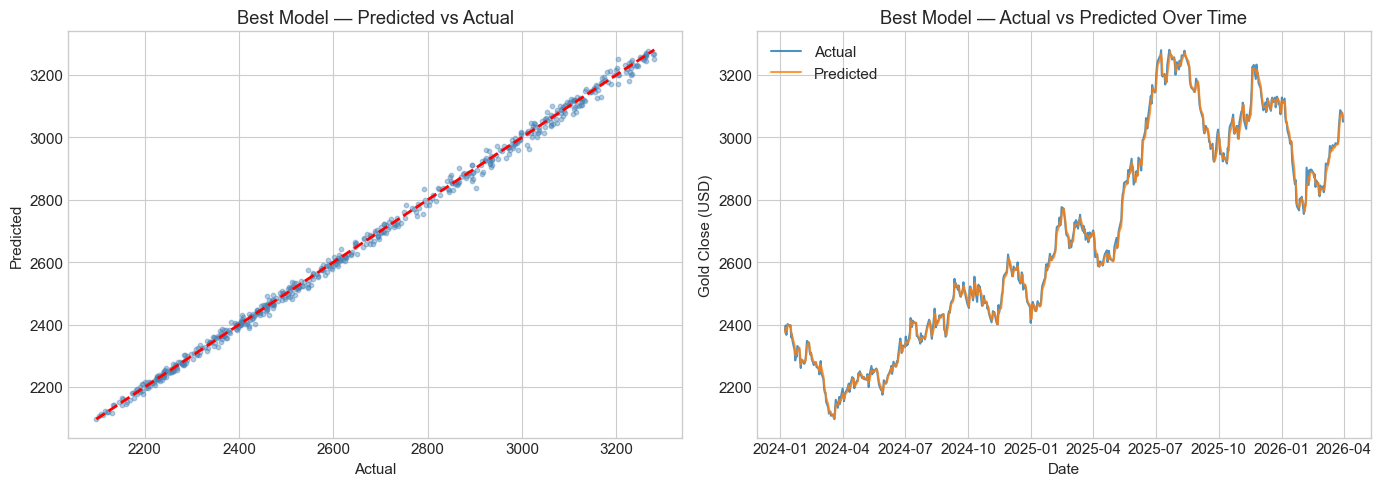

In [20]:
best_model = ridge_cv
y_pred_final = best_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_final, alpha=0.4, s=10, c='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Best Model — Predicted vs Actual')

axes[1].plot(y_test.index, y_test.values, label='Actual', alpha=0.8)
axes[1].plot(y_test.index, y_pred_final, label='Predicted', alpha=0.8)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Gold Close (USD)')
axes[1].set_title('Best Model — Actual vs Predicted Over Time')
axes[1].legend()

plt.tight_layout()
plt.savefig('best_model_results.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 9. Interpretation & Reflection

### What do the results tell us?

The lag features (especially `Gold_Lag_1`) turned out to be the most powerful predictors, which makes sense — in financial markets, today's price is usually very close to yesterday's. The DXY and other macro indicators also contributed, but the lag dominance shows that gold prices are highly autocorrelated.

Ridge and Multiple LR performed similarly, meaning regularization didn't change results drastically. This suggests the features are reasonably independent after scaling, though Ridge still helps control any remaining multicollinearity.

### Are the predictions useful?

The R² values are high, but this is somewhat misleading. Most of the predictive power comes from the lag feature, which essentially means the model is saying "tomorrow's price will be close to today's." For a trading strategy, we'd need to predict the *direction* or *magnitude of change* rather than the absolute price, which is a much harder problem.

### Main sources of error

- **Non-stationarity:** Gold prices trend upward over time, so the test set has generally higher prices than the training set. The model has to extrapolate somewhat.
- **Regime changes:** Market behavior during COVID or rate hike cycles is different from normal periods. A single linear model can't capture these shifts.
- **External shocks:** Sudden events (geopolitical crises, unexpected policy changes) create price jumps that no historical feature can predict.

### How this guides P3

In P3, I plan to:
- Try tree-based models (Random Forest, XGBoost) that can handle non-linear relationships and regime changes better
- Focus on predicting returns (daily change) instead of absolute price
- Use proper walk-forward validation that more realistically simulates real trading conditions

---
**GitHub:** [repositorhttps://github.com/AliBerkaySeucen/YZM2011-IMLy_link]